# 서울시 고령보행자 개별 교통사고 데이터 불러오기 및 저장


- 조회 대상: 서울시 고령보행자 사고
- 조회 기간: 2020년~2025년
- 수집 방식: `2020~2022`, `2023~2025` 두 기간을 각각 조회한 뒤 결합
- 서울시 법정동 코드 접두어: `11%`
- TAAS 간편조건 코드 `42`: 고령보행자 사고
- TAAS 원본 응답 좌표계: EPSG:5179
- 시각화용 변환 좌표계: EPSG:4326


In [1]:
import json
import re
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from shapely.geometry import Point

# 한글 폰트가 설치된 환경에서는 한글 제목/범례가 정상 표시됩니다.
plt.rcParams["font.family"] = ["NanumGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# TAAS GIS 화면을 먼저 열어야 합니다.
# 이 페이지 HTML 안에 CSRF 토큰이 들어 있고, 서버가 발급한 세션 쿠키도 함께 설정됩니다.
# 브라우저에서 TAAS 지도 화면을 열고 검색 버튼을 누르는 흐름을 Python requests로 재현하는 구조입니다.
TAAS_INIT_URL = "https://taas.koroad.or.kr/gis/mcm/mcl/initMap.do?menuId=GIS_PAE_PTA"

# TAAS 지도 화면이 내부적으로 호출하는 개별사고 조회 엔드포인트입니다.
# 공공데이터포털의 다발지역 API가 아니라, TAAS GIS 웹 화면의 Ajax 요청 주소입니다.
TAAS_ACCIDENT_URL = "https://taas.koroad.or.kr/gis/srh/ash/selectAccidentInfo.do"

# 요청을 두 기간으로 나누어 수행한 뒤 2020~2025 데이터로 결합합니다.
# TAAS는 startAcdntYear/endAcdntYear 형태로 기간 조건을 받습니다.
QUERY_PERIODS = [("2020", "2022"), ("2023", "2025")]

# 서울시 법정동코드 접두어입니다.
# TAAS는 시군구 단위 조회 시 legaldongCode에 '11%'처럼 LIKE 조건용 값을 전달합니다.
TARGET_LEGALDONG_PREFIX = "11%"

# TAAS 간편조건 코드입니다.
# TAAS JavaScript에서 conditionCode 42는 SQL 조건 (ACC_CLS_52YN = '1')로 매핑되며,
# 주석상 의미는 '고령보행자 사고'입니다.
OLD_PEDESTRIAN_CONDITION_CODE = "42"

# 노트북이 프로젝트 루트에서 실행된다는 전제입니다.
# 결과 파일은 프로젝트 하위 Data 폴더에 저장합니다.
DATA_DIR = Path("Data")
OUTPUT_CSV = DATA_DIR / "seoul_old_pedestrian_individual_accidents_2020_2025.csv"
OUTPUT_GEOJSON = DATA_DIR / "seoul_old_pedestrian_individual_accidents_2020_2025.geojson"
OUTPUT_HTML = DATA_DIR / "seoul_old_pedestrian_individual_accidents_2020_2025.html"

In [3]:
def make_taas_session():
    """TAAS GIS 페이지에서 CSRF 토큰을 받은 뒤 API 호출용 세션과 헤더를 만듭니다."""
    # requests.Session()은 브라우저의 탭처럼 쿠키를 보관합니다.
    # TAAS는 첫 지도 페이지 요청에서 세션 쿠키와 CSRF 토큰을 발급하므로,
    # 이후 Ajax POST 요청도 반드시 같은 session 객체로 보내야 합니다.
    session = requests.Session()

    # 1단계: TAAS GIS 초기 화면 HTML을 요청합니다.
    # 이 요청은 실제 사고 데이터를 가져오는 요청이 아니라, 인증 토큰과 쿠키를 받기 위한 준비 단계입니다.
    response = session.get(TAAS_INIT_URL, timeout=30)
    response.raise_for_status()

    # 2단계: HTML <meta name="_csrf" ...> 태그에서 CSRF 토큰을 추출합니다.
    # TAAS 서버는 Ajax 요청 헤더에 이 값을 요구합니다.
    match = re.search(r'<meta name="_csrf"[^>]*content="([^"]+)"', response.text)
    if match is None:
        raise RuntimeError("TAAS GIS 페이지에서 CSRF 토큰을 찾지 못했습니다.")

    csrf_token = match.group(1)

    # 3단계: 브라우저 Ajax 요청처럼 보이도록 필요한 헤더를 구성합니다.
    # X-CSRF-TOKEN: 위에서 추출한 토큰
    # X-Requested-With: TAAS가 내부 Ajax 호출로 인식할 때 쓰는 관례적 헤더
    # Referer: 어떤 TAAS 화면에서 호출했는지 알려주는 헤더
    headers = {
        "Accept": "application/json, text/javascript, */*; q=0.01",
        "Content-Type": "application/json;charset=UTF-8",
        "Referer": TAAS_INIT_URL,
        "X-CSRF-TOKEN": csrf_token,
        "X-Requested-With": "XMLHttpRequest",
    }
    return session, headers


def fetch_target_old_pedestrian_accidents(session, headers, start_year, end_year):
    # 4단계: TAAS 지도 화면의 사고검색 조건을 JSON payload로 구성합니다.
    # 아래 값들은 TAAS JavaScript가 selectAccidentInfo.do로 보내는 값과 같은 형태입니다.
    payload = {
        "searchType": "00",          # 일반 사고검색
        "pageIndex": 1,              # 첫 페이지. 이 엔드포인트는 조건 결과 전체 목록도 함께 내려줍니다.
        "zoneYn": False,             # 보호구역/다발지역 검색이 아니라 일반 사고검색
        "engnCode": "00",           # TAAS 내부 엔진/자료 구분값
        "startAcdntYear": start_year,
        "endAcdntYear": end_year,
        "legaldongCode": TARGET_LEGALDONG_PREFIX,
        "searchSimpleCondition": OLD_PEDESTRIAN_CONDITION_CODE,
    }

    # 5단계: 같은 세션과 CSRF 헤더로 개별사고 조회 Ajax POST를 보냅니다.
    # 응답의 resultValue.accidentInfoList가 개별 사고 목록입니다.
    response = session.post(TAAS_ACCIDENT_URL, headers=headers, data=json.dumps(payload), timeout=60)
    response.raise_for_status()
    data = response.json()

    if "resultValue" not in data:
        raise RuntimeError(f"예상하지 못한 TAAS 응답입니다: {data}")

    result_value = data["resultValue"]
    rows = result_value.get("accidentInfoList") or []
    pagination = result_value.get("paginationInfo") or {}

    for row in rows:
        row["query_start_year"] = start_year
        row["query_end_year"] = end_year
        row["query_period"] = f"{start_year}~{end_year}"

    print(f"{start_year}~{end_year} TAAS 총 레코드 수: {pagination.get('totalRecordCount', len(rows)):,}")
    print(f"{start_year}~{end_year} 수집된 개별사고 수: {len(rows):,}")
    return rows, pagination


session, headers = make_taas_session()
all_rows = []
pagination_by_period = {}

for start_year, end_year in QUERY_PERIODS:
    period_rows, period_pagination = fetch_target_old_pedestrian_accidents(
        session=session,
        headers=headers,
        start_year=start_year,
        end_year=end_year,
    )
    all_rows.extend(period_rows)
    pagination_by_period[f"{start_year}~{end_year}"] = period_pagination

accident_df = pd.DataFrame(all_rows)

if accident_df.empty:
    raise ValueError("조회된 서울시 고령보행자 개별사고 데이터가 없습니다.")

# 두 기간이 겹치지는 않지만, 안전하게 사고번호 기준 중복을 제거합니다.
accident_df = accident_df.drop_duplicates(subset=["acdnt_no"]).reset_index(drop=True)

print(f"2020~2025 결합 후 개별사고 수: {len(accident_df):,}")
display(accident_df.head())

2020~2022 TAAS 총 레코드 수: 5,373
2020~2022 수집된 개별사고 수: 5,373
2023~2025 TAAS 총 레코드 수: 5,996
2023~2025 수집된 개별사고 수: 5,996
2020~2025 결합 후 개별사고 수: 11,369


,searchConditionText,searchCondition,searchKeyword,pageIndex,pageUnit,recordCountPerPage,zoneYn,acdnt_no,engn_code,acdnt_year,...,acdnt_frm_lv3,acdnt_sta_lv1,acdnt_sta_lv2,rde_id,rde_nm,serial_no,rn,query_start_year,query_end_year,query_period
0,,,,1,3,10,False,2020010100100198,00,2020,...,None,None,None,None,None,2020000192,None,2020,2022,2020~2022
1,,,,1,3,10,False,2020010100100286,00,2020,...,None,None,None,None,None,2020000276,None,2020,2022,2020~2022
2,,,,1,3,10,False,2020010100100288,00,2020,...,None,None,None,None,None,2020000278,None,2020,2022,2020~2022
3,,,,1,3,10,False,2020010100100333,00,2020,...,None,None,None,None,None,2020000323,None,2020,2022,2020~2022
4,,,,1,3,10,False,2020010200100036,00,2020,...,None,None,None,None,None,2020000388,None,2020,2022,2020~2022


In [4]:
# TAAS 응답의 좌표와 사상자 수 컬럼은 문자열로 올 수 있으므로 숫자로 변환합니다.
# x_crdnt/y_crdnt는 TAAS 지도에서 쓰는 EPSG:5179 평면좌표입니다.
numeric_cols = [
    "acdnt_year",
    "x_crdnt",
    "y_crdnt",
    "dprs_cnt",
    "sep_cnt",
    "slp_cnt",
    "inj_aplcnt_cnt",
]

for col in numeric_cols:
    if col in accident_df.columns:
        accident_df[col] = pd.to_numeric(accident_df[col], errors="coerce")

# 좌표가 없는 행은 지도에 표시할 수 없으므로 제외합니다.
accident_df = accident_df.dropna(subset=["x_crdnt", "y_crdnt"]).copy()

# 6단계: TAAS 원본 좌표계(EPSG:5179)로 Point geometry를 만듭니다.
# 서울시 도로 데이터와 결합할 때는 이 accident_gdf_5179를 사용하면 됩니다.
accident_gdf_5179 = gpd.GeoDataFrame(
    accident_df,
    geometry=[Point(xy) for xy in zip(accident_df["x_crdnt"], accident_df["y_crdnt"])],
    crs="EPSG:5179",
)

# 7단계: 일반 웹지도와 Plotly/OpenStreetMap에서 쓰기 편한 위경도 좌표계(EPSG:4326)로 변환합니다.
# 시각화용 accident_gdf는 EPSG:4326이고, 결합용 원본은 accident_gdf_5179입니다.
accident_gdf = accident_gdf_5179.to_crs(epsg=4326)
accident_gdf["lon"] = accident_gdf.geometry.x
accident_gdf["lat"] = accident_gdf.geometry.y

print(f"EPSG:5179 원본 포인트: {len(accident_gdf_5179):,}건")
print(f"EPSG:4326 변환 포인트: {len(accident_gdf):,}건")
display(accident_gdf[["acdnt_no", "acdnt_year", "acdnt_dd_dc", "occrrnc_time_dc", "acdnt_dc", "acdnt_gae_dc", "acdnt_pos", "lon", "lat"]].head())

EPSG:5179 원본 포인트: 11,369건
EPSG:4326 변환 포인트: 11,369건


,acdnt_no,acdnt_year,acdnt_dd_dc,occrrnc_time_dc,acdnt_dc,acdnt_gae_dc,acdnt_pos,lon,lat
0,2020010100100198,2020,2020년 1월,15시,차대사람 - 기타,경상사고,None,127.032314,37.666424
1,2020010100100286,2020,2020년 1월,19시,차대사람 - 횡단중,중상사고,앞 도로,127.048491,37.577002
2,2020010100100288,2020,2020년 1월,19시,차대사람 - 횡단중,경상사고,None,127.128676,37.551215
3,2020010100100333,2020,2020년 1월,21시,차대사람 - 횡단중,경상사고,앞 횡단보도(삼성역사거리에서 봉은사역사거리 방향) 코엑스 동문방향 건널목,127.062025,37.511110
4,2020010200100036,2020,2020년 1월,06시,차대사람 - 횡단중,중상사고,None,126.850300,37.525206


In [5]:
year_summary = (
    accident_gdf.groupby("acdnt_year", as_index=False)
    .agg(
        사고건수=("acdnt_no", "size"),
        사망자수=("dprs_cnt", "sum"),
        중상자수=("sep_cnt", "sum"),
        경상자수=("slp_cnt", "sum"),
        부상신고자수=("inj_aplcnt_cnt", "sum"),
    )
    .sort_values("acdnt_year")
)

type_summary = (
    accident_gdf.groupby(["acdnt_year", "acdnt_gae_dc"], as_index=False)
    .agg(사고건수=("acdnt_no", "size"))
    .sort_values(["acdnt_year", "acdnt_gae_dc"])
)

display(year_summary)
display(type_summary)

,acdnt_year,사고건수,사망자수,중상자수,경상자수,부상신고자수
0,2020,1805,61,995,784,91
1,2021,1722,71,934,763,79
2,2022,1846,66,918,856,122
3,2023,1973,48,1017,960,150
4,2024,1963,70,981,920,144
5,2025,2060,83,1071,931,102


,acdnt_year,acdnt_gae_dc,사고건수
0,2020,경상사고,701
1,2020,부상신고사고,79
2,2020,사망사고,61
3,2020,중상사고,964
4,2021,경상사고,689
5,2021,부상신고사고,63
6,2021,사망사고,69
7,2021,중상사고,901
8,2022,경상사고,774
9,2022,부상신고사고,102


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not 

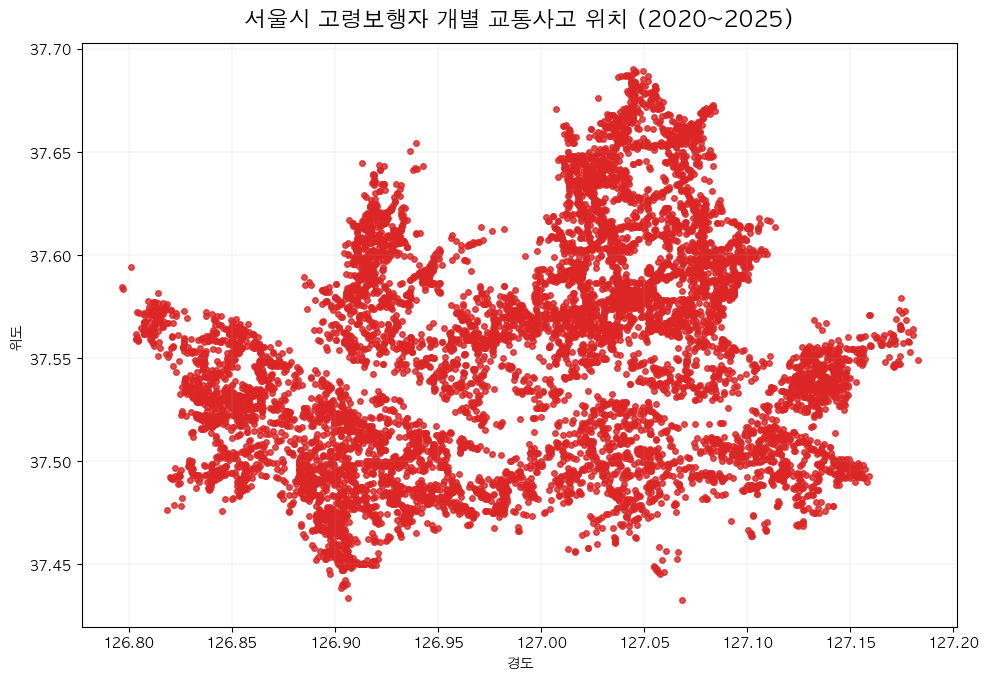

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

accident_gdf.plot(
    ax=ax,
    color="#dc2626",
    markersize=16,
    alpha=0.82,
)

ax.set_title("서울시 고령보행자 개별 교통사고 위치 (2020~2025)", fontsize=16, pad=12)
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.set_aspect("equal")
ax.grid(True, linewidth=0.3, alpha=0.4)

plt.tight_layout()
plt.show()

In [7]:
try:
    import plotly.express as px

    plot_df = accident_gdf.copy()
    plot_df["사고정보"] = (
        plot_df["acdnt_dd_dc"].astype(str)
        + " " + plot_df["occrrnc_time_dc"].astype(str)
        + "<br>유형: " + plot_df["acdnt_dc"].astype(str)
        + "<br>내용: " + plot_df["acdnt_gae_dc"].astype(str)
        + "<br>위치: " + plot_df["acdnt_pos"].fillna("").astype(str)
    )

    fig = px.scatter_mapbox(
        plot_df,
        lat="lat",
        lon="lon",
        color="acdnt_year",
        hover_name="acdnt_no",
        hover_data={
            "사고정보": True,
            "lat": False,
            "lon": False,
            "acdnt_year": True,
        },
        zoom=12,
        height=760,
        title="서울시 고령보행자 개별 교통사고 위치 (2020~2025)",
    )
    fig.update_layout(mapbox_style="open-street-map", margin={"r": 0, "t": 45, "l": 0, "b": 0})
    fig.show()
    fig.write_html(OUTPUT_HTML)
except ImportError:
    print("plotly가 설치되어 있지 않아 대화형 지도 셀을 건너뜁니다.")

/var/folders/jt/3nmxlhnj59354djyf6z18tqw0000gn/T/ipykernel_30178/3208221735.py:13: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [8]:
# Data 폴더에 2020~2025 결합 결과를 CSV로 저장합니다.
# geometry는 CSV에 직접 저장하지 않고, 원본 좌표 x_crdnt/y_crdnt와 변환 좌표 lon/lat를 컬럼으로 저장합니다.
accident_gdf.drop(columns="geometry").to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"CSV 저장: {OUTPUT_CSV}")

CSV 저장: Data/seoul_old_pedestrian_individual_accidents_2020_2025.csv
